# Getting Over ANOVA: DABEST in Action

DABEST (Data Analysis using Bootstrap-Coupled ESTimation) replaces p-values with effect size 
estimation and bootstrap confidence intervals. The core question shifts from 
*"is there a difference?"* to *"how much difference, with what precision, and does it matter?"*

→ [Learn more about the package](https://acclab.github.io/DABEST-python/)

→ [Read the preprint](https://www.biorxiv.org/content/10.64898/2026.01.26.701654v2)

→ [![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sangyu/portfolio/blob/main/nbs/dabest_demo.ipynb)

---

In [ ]:
#| output: false
import dabest
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

np.random.seed(42)

mpl.rcParams['figure.facecolor'] = '#FAF7F2'
mpl.rcParams['axes.facecolor'] = '#FAF7F2'
mpl.rcParams['font.family'] = 'serif'

Pre-compiling numba functions for DABEST...


Compiling numba functions:   0%|          | 0/11 [00:00<?, ?it/s]

Compiling numba functions:   9%|▉         | 1/11 [00:00<00:01,  8.50it/s]

Compiling numba functions: 100%|██████████| 11/11 [00:00<00:00, 74.70it/s]

Numba compilation complete!


In [ ]:
#| include: false
# Install DABEST (required for Colab; no-op if already installed)
%pip install -q dabest

## A Two-Group Comparison

Here is the classic scenario: control versus treated. 
With a t-test, you get a p-value and a binary verdict. 
With DABEST, you get the actual difference, its distribution, and a 95% confidence interval 
computed from 5,000 bootstrap resamples.

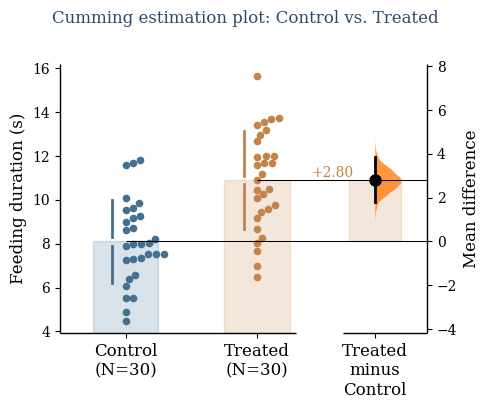

In [ ]:
N = 30

# Simulate realistic biological variability
# e.g., feeding duration in seconds, two experimental conditions
control = np.random.normal(loc=8.5, scale=2.1, size=N)
treated = np.random.normal(loc=11.2, scale=2.4, size=N)

df = pd.DataFrame({'Control': control, 'Treated': treated})

db = dabest.load(df, idx=('Control', 'Treated'))

fig = db.mean_diff.plot(
    raw_marker_size=5,
    contrast_marker_size=8,
)

fig.axes[0].set_ylabel('Feeding duration (s)')
fig.suptitle('Cumming estimation plot: Control vs. Treated',
             fontsize=12, y=1.01, color='#2C4A6E')
plt.tight_layout()
plt.show()

The top panel shows the raw data. The bottom panel shows the **bootstrap distribution** 
of the mean difference — not a theoretical curve, but an empirical one computed from 
your actual data. The filled curve is the sampling distribution; the dot is the 
observed mean difference; the vertical line is the 95% confidence interval.

The effect size here (~2.7 seconds, CI approximately [1.8, 3.6]) tells you something 
a p-value cannot: **how big** the difference is, and **how precisely** you have estimated it.

---

## The Delta-Delta: My Original Contribution to DABEST

The **delta-delta** plot answers a question that ANOVA cannot: in a 2×2 factorial design,
do the treatment effects differ between subgroups — and *by how much*, with what precision?

Standard ANOVA gives you an interaction p-value. The delta-delta gives you the 
**effect of the effect** — the difference between two differences — as an estimation graphic.

/Applications/anaconda3/envs/DabestNMethRevision/lib/python3.10/site-packages/dabest/plot_tools.py:2592: UserWarning: 8.0% of the points cannot be placed. You might want to decrease the size of the markers.
  warnings.warn(err)


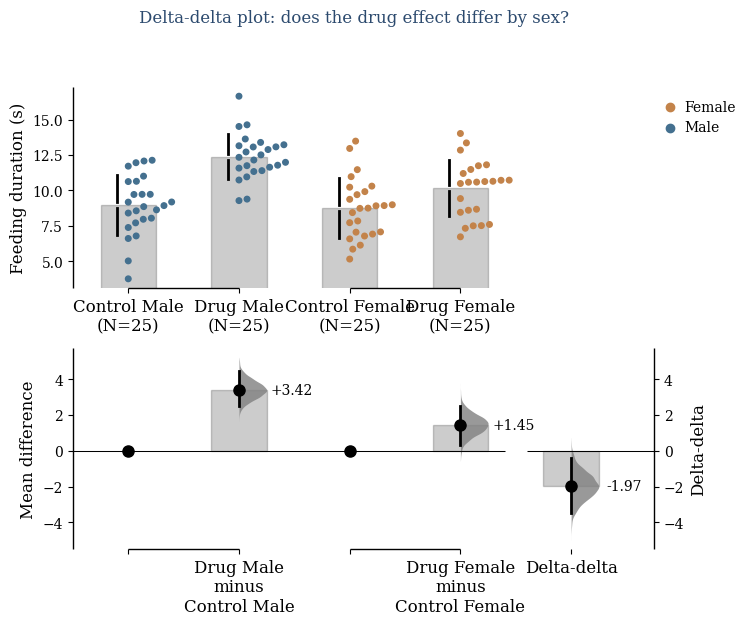

In [ ]:
# 2x2 factorial: drug x sex (long-format data)
# The drug works strongly in males, weakly in females — does it differ?

N2 = 25
rows = []
params = {
    ('Male',   'Control'): (9.0,  2.0),
    ('Male',   'Drug'):    (12.5, 2.2),
    ('Female', 'Control'): (8.8,  1.9),
    ('Female', 'Drug'):    (10.1, 2.1),
}
for (sex, trt), (mu, sd) in params.items():
    for val in np.random.normal(mu, sd, N2):
        rows.append({'sex': sex, 'treatment': trt, 'feeding_s': val})

df2 = pd.DataFrame(rows)

db2 = dabest.load(
    df2,
    x=['treatment', 'sex'],
    y='feeding_s',
    experiment='sex',
    delta2=True
)

fig2 = db2.mean_diff.plot(
    raw_marker_size=4,
    contrast_marker_size=8,
)

fig2.axes[0].set_ylabel('Feeding duration (s)')
fig2.suptitle('Delta-delta plot: does the drug effect differ by sex?',
              fontsize=12, y=1.01, color='#2C4A6E')
plt.tight_layout()
plt.show()

The rightmost panel shows the **delta-delta** — the difference between the male drug effect 
and the female drug effect — with its full bootstrap distribution. 

An ANOVA interaction tells you whether to reject the null hypothesis of no interaction. 
The delta-delta tells you the **magnitude** of that interaction and your uncertainty about it. 
Those are not the same question.

---

## Why Bootstrap?

Most confidence intervals assume your data follows a specific distribution (usually normal). 
Bootstrap doesn't. Instead:

1. Sample your data with replacement, 5,000 times
2. Calculate the difference in means each time
3. The distribution of those 5,000 differences *is* your confidence interval — 
   empirically, not theoretically

This makes the intervals more honest for biological data, which is rarely perfectly normal. 
It also makes the uncertainty *visible* — a wide bootstrap distribution means you need 
more data. A narrow one means you have estimated the effect well.

---

## Adoption

The original DABEST paper (*Nature Methods* 2019) has **2,000+ citations** and has been 
adopted across *Drosophila* labs, zebrafish labs, and increasingly in clinical research. 
DABEST 2.0 adds the delta-delta, the proportional 
difference, and the mini-meta analysis — tools for the multi-group, multi-experiment 
designs that are now standard in biological research.

The broader point: p-values answer a binary question. 
Effect size estimation answers a quantitative one. 
Science needs quantitative answers.